# Reducing the Size of Large Models: Quantization of BERT and LLaMA

**Question:** Models like BERT or LLaMA are very large. How can we address this issue? Discuss quantization as a solution to reduce model size, with code examples.

**Notebook outline**
1. The problem: why model size matters
2. Overview of size-reduction techniques
3. Quantization theory (with LaTeX)
4. Quantization from scratch (NumPy)
5. Fake quantization and QAT (PyTorch)
6. Quantizing a real BERT model (dynamic INT8)
7. Quantizing a LLaMA-family model (8-bit / 4-bit with `bitsandbytes`)
8. Results comparison
9. Discussion and conclusion
10. References

> Sections 6 and 7 download models from Hugging Face. Run them in Google Colab. Section 7 needs a GPU (Runtime → Change runtime type → T4).

In [1]:
!pip -q install transformers accelerate bitsandbytes sentencepiece pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.8 MB/s eta 0:00:00


In [2]:
import os, time, gc, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

np.random.seed(0)
torch.manual_seed(0)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## 1. The Problem: Why Model Size Matters

A model's memory footprint is simply

$$
\text{Memory (bytes)} = N_{\text{params}} \times \frac{b}{8}
$$

where $b$ is the number of bits used per parameter. Standard training uses FP32 ($b=32$, i.e. 4 bytes per weight).

Why this is a practical problem:

| Issue | Consequence |
|---|---|
| **GPU/CPU memory** | LLaMA-7B in FP32 needs ~28 GB for weights alone, which does not fit on most GPUs |
| **Disk & download size** | Slow distribution, expensive storage |
| **Inference latency** | Inference is often *memory-bandwidth bound*: every weight must be read from memory for each token |
| **Energy / cost** | Moving data costs more energy than arithmetic |
| **Edge deployment** | Phones and embedded devices have a few GB of RAM at most |

Let us compute the sizes.

In [3]:
models = {            # approximate parameter counts
    "BERT-base":  110e6,
    "BERT-large": 340e6,
    "LLaMA-7B":   7e9,
    "LLaMA-13B":  13e9,
    "LLaMA-70B":  70e9,
}
precisions = {"FP32": 32, "FP16": 16, "INT8": 8, "INT4": 4}

size_gb = pd.DataFrame({
    p: {m: n * b / 8 / 1e9 for m, n in models.items()} for p, b in precisions.items()
})
size_gb.round(2)

,FP32,FP16,INT8,INT4
BERT-base,0.44,0.22,0.11,0.06
BERT-large,1.36,0.68,0.34,0.17
LLaMA-7B,28.00,14.00,7.00,3.50
LLaMA-13B,52.00,26.00,13.00,6.50
LLaMA-70B,280.00,140.00,70.00,35.00


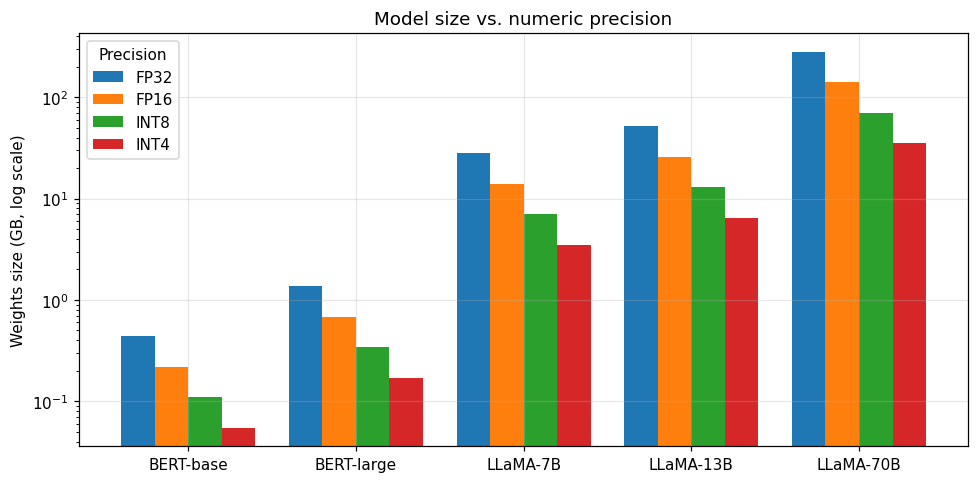

In [4]:
ax = size_gb.plot(kind="bar", figsize=(9, 4.5), logy=True, width=0.8)
ax.set_ylabel("Weights size (GB, log scale)")
ax.set_title("Model size vs. numeric precision")
plt.xticks(rotation=0)
plt.legend(title="Precision")
plt.tight_layout()
plt.show()

**Observation:** going from FP32 to INT8 cuts memory by $4\times$, and to INT4 by $8\times$. LLaMA-70B drops from 280 GB to 35 GB (INT4), which is the difference between a GPU cluster and a single high-end GPU.

## 2. Overview of Size-Reduction Techniques

| Technique | Idea | Changes architecture? |
|---|---|---|
| **Quantization** | Store weights (and possibly activations) with fewer bits | No |
| **Pruning** | Remove weights, neurons, heads, or layers that contribute little | Yes (sparse or smaller) |
| **Knowledge distillation** | Train a small *student* to mimic a large *teacher* (e.g. DistilBERT) | Yes (new smaller model) |
| **Low-rank factorization** | Approximate $W \in \mathbb{R}^{m\times n}$ by $AB$ with $A\in\mathbb{R}^{m\times r}$, $B\in\mathbb{R}^{r\times n}$, $r \ll \min(m,n)$ | Yes |
| **Weight sharing** | Reuse the same parameters across layers (e.g. ALBERT) | Yes |

**Why quantization?** It needs no retraining in its simplest form (post-training), keeps the architecture unchanged, works on any pretrained model, and gives predictable savings ($32/b$). It also combines with the other techniques (e.g. QLoRA = 4-bit quantization + low-rank adapters).

## 3. Quantization Theory

**Quantization** maps values from a large (continuous or high-precision) set to a smaller discrete set. For neural networks: FP32 weights are mapped to low-bit integers plus a small amount of metadata (scale, zero-point) used to map back.

### 3.1 Number formats

| Format | Bits | Layout (sign / exponent / mantissa) | Notes |
|---|---|---|---|
| FP32 | 32 | 1 / 8 / 23 | default training format |
| FP16 | 16 | 1 / 5 / 10 | narrower range, can overflow |
| BF16 | 16 | 1 / 8 / 7 | same range as FP32, lower precision |
| INT8 | 8 | integer in $[-128,127]$ or $[0,255]$ | 256 levels |
| INT4 | 4 | integer in $[-8,7]$ or $[0,15]$ | 16 levels |

### 3.2 Affine (asymmetric) quantization

Given a real value $x$ in the range $[x_{\min}, x_{\max}]$ and a $b$-bit unsigned integer range $[q_{\min}, q_{\max}] = [0,\,2^b-1]$:

$$
s = \frac{x_{\max} - x_{\min}}{q_{\max} - q_{\min}} = \frac{x_{\max} - x_{\min}}{2^{b}-1}
$$

$$
z = \operatorname{round}\!\left(q_{\min} - \frac{x_{\min}}{s}\right)
$$

$$
q = \operatorname{clamp}\!\Big(\operatorname{round}\!\big(\tfrac{x}{s}\big) + z,\; q_{\min},\; q_{\max}\Big)
$$

Here $s$ is the **scale** (the real-valued step between adjacent integer levels) and $z$ is the **zero-point** (the integer that represents real $0$ exactly, which matters for zero padding and ReLU outputs).

**Derivation of $s$:** we have $2^b$ integer levels covering the range $x_{\max}-x_{\min}$, i.e. $2^b-1$ equal intervals, so each interval has width $s=\frac{x_{\max}-x_{\min}}{2^b-1}$.

### 3.3 Dequantization

$$
\hat{x} = s\,(q - z)
$$

Because of rounding, $\hat{x} \neq x$ in general. The **quantization error** is

$$
\varepsilon = x - \hat{x}, \qquad |\varepsilon| \le \frac{s}{2} \ \text{(for values inside the range)}
$$

and we measure it over a tensor with the mean squared error

$$
\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}\left(x_i - \hat{x}_i\right)^2
$$

Since $s \propto 2^{-b}$, **each bit removed doubles the step size** and roughly quadruples the MSE (MSE $\propto s^2/12$ for uniformly distributed rounding error).

### 3.4 Symmetric quantization

The range is centred on zero and the zero-point is fixed at $z = 0$. With signed integers in $[-(2^{b-1}-1),\, 2^{b-1}-1]$:

$$
s = \frac{\max_i |x_i|}{2^{b-1}-1}, \qquad q = \operatorname{clamp}\!\big(\operatorname{round}(x/s),\,-(2^{b-1}-1),\,2^{b-1}-1\big), \qquad \hat{x} = s\,q
$$

Symmetric is simpler and faster (no zero-point term in the integer matmul) and suits weights, which are roughly zero-centred. Asymmetric is better for skewed distributions such as post-ReLU activations.

### 3.5 Types of quantization

* **Post-Training Quantization (PTQ)**: quantize an already-trained model.
  * *Dynamic*: weights quantized offline, activation scales computed on the fly at inference. No calibration data needed.
  * *Static*: activation scales are fixed in advance using a small **calibration dataset**.
* **Quantization-Aware Training (QAT)**: simulate quantization during training with **fake quantization** ($\hat{x}=s\,(\operatorname{clamp}(\operatorname{round}(x/s)+z)-z)$ in the forward pass) and use the **straight-through estimator (STE)** in the backward pass, because $\operatorname{round}$ has zero gradient almost everywhere:

$$
\frac{\partial \hat{x}}{\partial x} \approx \begin{cases}1 & x_{\min}\le x\le x_{\max}\\ 0 & \text{otherwise}\end{cases}
$$

### 3.6 Granularity

| Granularity | One scale per | Trade-off |
|---|---|---|
| Per-tensor | whole weight matrix | simplest, most sensitive to outliers |
| Per-channel | output row/column | better accuracy, small overhead |
| Per-group | block of e.g. 64 or 128 weights | standard for 4-bit LLM quantization (GPTQ, AWQ, NF4 blocks) |

### 3.7 Trade-offs

* **Accuracy loss** grows as bit-width drops; 8-bit is usually near-lossless, 4-bit needs care.
* **Outliers** stretch $[x_{\min},x_{\max}]$, which increases $s$ and wastes levels on the bulk of the values (we demonstrate this below). Large LLMs develop systematic outlier activation channels, which is the motivation for LLM.int8().
* **Hardware support** matters: real speed-ups require INT8/INT4 kernels.

## 4. Quantization from Scratch (NumPy)

In [5]:
def quantize_affine(x, num_bits=8):
    # Asymmetric quantization to unsigned integers [0, 2^b - 1].
    qmin, qmax = 0, 2 ** num_bits - 1
    x_min, x_max = float(x.min()), float(x.max())
    scale = (x_max - x_min) / (qmax - qmin)
    zero_point = int(np.clip(np.round(qmin - x_min / scale), qmin, qmax))
    q = np.clip(np.round(x / scale) + zero_point, qmin, qmax).astype(np.int32)
    return q, scale, zero_point

def dequantize_affine(q, scale, zero_point):
    return scale * (q.astype(np.float32) - zero_point)

def quantize_symmetric(x, num_bits=8):
    # Symmetric quantization to signed integers, zero-point = 0.
    qmax = 2 ** (num_bits - 1) - 1
    scale = np.abs(x).max() / qmax
    q = np.clip(np.round(x / scale), -qmax, qmax).astype(np.int32)
    return q, scale

def dequantize_symmetric(q, scale):
    return scale * q.astype(np.float32)

def mse(a, b):
    return float(np.mean((a - b) ** 2))

### 4.1 A first example on a small tensor

In [6]:
x = np.array([-1.2, -0.5, 0.0, 0.3, 0.9, 1.7], dtype=np.float32)
q, s, z = quantize_affine(x, num_bits=8)
x_hat = dequantize_affine(q, s, z)

print("original     :", x)
print("quantized    :", q)
print(f"scale={s:.5f}, zero_point={z}")
print("dequantized  :", x_hat.round(4))
print("abs error    :", np.abs(x - x_hat).round(5), f"(<= s/2 = {s/2:.5f})")

original     : [-1.2 -0.5  0.   0.3  0.9  1.7]
quantized    : [  0  62 106 132 185 255]
scale=0.01137, zero_point=106
dequantized  : [-1.2055 -0.5004  0.      0.2957  0.8984  1.6945]
abs error    : [0.00549 0.00039 0.      0.00431 0.00157 0.00549] (<= s/2 = 0.00569)


### 4.2 Error vs. bit-width on BERT-like weights

Trained transformer weights are approximately Gaussian with a small standard deviation. We simulate a $768\times768$ matrix (the size of a BERT-base projection layer).

In [7]:
W = np.random.normal(0, 0.04, size=(768, 768)).astype(np.float32)

bits_list = [2, 3, 4, 5, 6, 8]
rows = []
for b in bits_list:
    qa, sa, za = quantize_affine(W, b)
    qs, ss = quantize_symmetric(W, b)
    rows.append({
        "bits": b,
        "MSE affine":    mse(W, dequantize_affine(qa, sa, za)),
        "MSE symmetric": mse(W, dequantize_symmetric(qs, ss)),
        "max err affine": float(np.abs(W - dequantize_affine(qa, sa, za)).max()),
    })
err_df = pd.DataFrame(rows).set_index("bits")
err_df

,MSE affine,MSE symmetric,max err affine
bits,,,
2,1.119369e-03,1.534853e-03,0.063859
3,2.498934e-04,3.707169e-04,0.027368
4,5.434037e-05,6.807500e-05,0.012772
5,1.274596e-05,1.484584e-05,0.006180
6,3.081158e-06,3.475588e-06,0.003041
8,1.877758e-07,2.069858e-07,0.000751


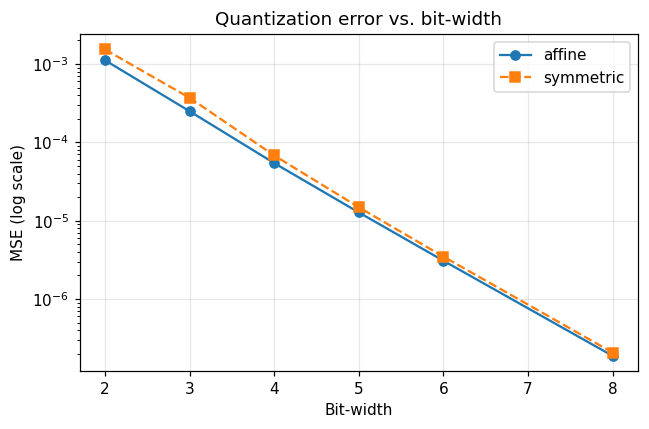

In [8]:
plt.figure(figsize=(6, 4))
plt.semilogy(err_df.index, err_df["MSE affine"], "o-", label="affine")
plt.semilogy(err_df.index, err_df["MSE symmetric"], "s--", label="symmetric")
plt.xlabel("Bit-width"); plt.ylabel("MSE (log scale)")
plt.title("Quantization error vs. bit-width")
plt.legend(); plt.tight_layout(); plt.show()

The error drops roughly $4\times$ per extra bit, matching the theory ($\text{MSE}\propto s^2 \propto 4^{-b}$).

### 4.3 Original vs. dequantized weight distributions

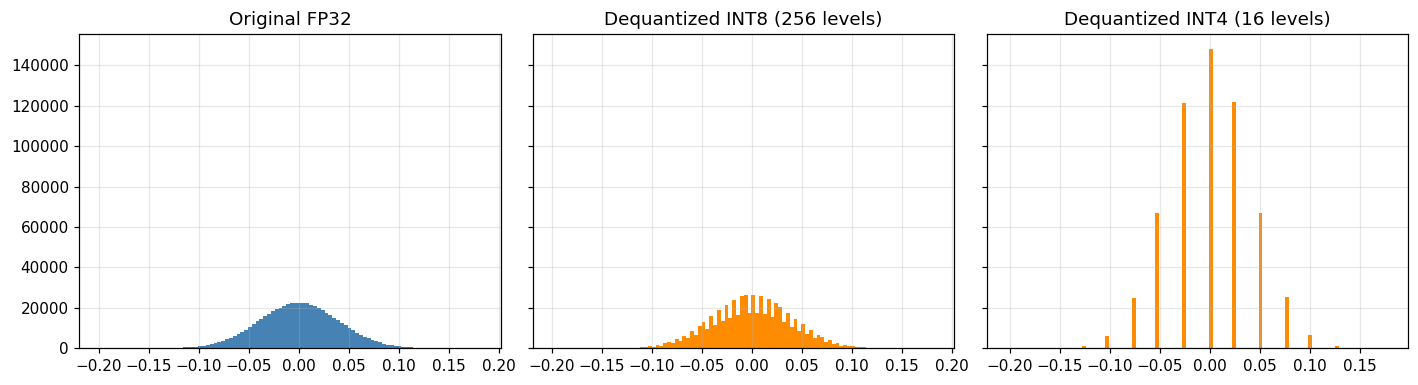

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
axes[0].hist(W.ravel(), bins=100, color="steelblue"); axes[0].set_title("Original FP32")
for ax, b in zip(axes[1:], [8, 4]):
    q, s, z = quantize_affine(W, b)
    ax.hist(dequantize_affine(q, s, z).ravel(), bins=100, color="darkorange")
    ax.set_title(f"Dequantized INT{b} ({2**b} levels)")
plt.tight_layout(); plt.show()

### 4.4 Visualising the mapping (FP32 → 4-bit grid)

Every real value is snapped to the nearest of only 16 grid points.

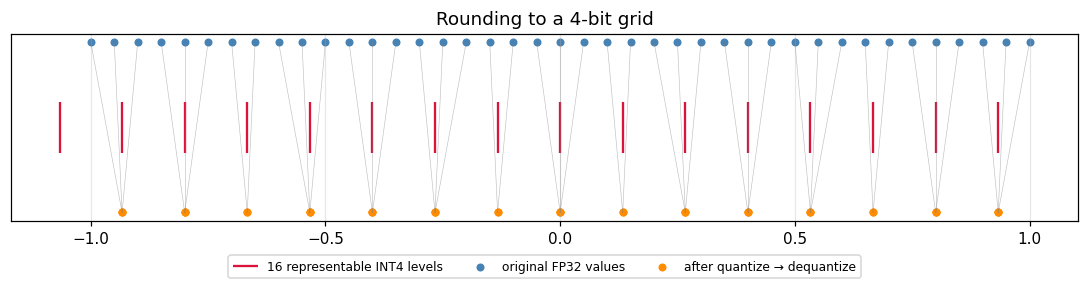

In [10]:
xs = np.linspace(-1, 1, 41).astype(np.float32)
q, s, z = quantize_affine(xs, 4)
xh = dequantize_affine(q, s, z)
grid = dequantize_affine(np.arange(16), s, z)

plt.figure(figsize=(10, 2.8))
plt.vlines(grid, -0.15, 0.15, colors="crimson", label="16 representable INT4 levels")
plt.scatter(xs, np.full_like(xs, 0.5), s=18, color="steelblue", label="original FP32 values")
plt.scatter(xh, np.full_like(xh, -0.5), s=18, color="darkorange", label="after quantize → dequantize")
for a, b_ in zip(xs, xh):
    plt.plot([a, b_], [0.5, -0.5], color="gray", lw=0.4, alpha=0.5)
plt.yticks([]); plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8)
plt.title("Rounding to a 4-bit grid"); plt.tight_layout(); plt.show()

### 4.5 The outlier problem and per-channel quantization

A single large value inflates $x_{\max}$, so the scale $s$ grows and the bulk of the weights are represented with very few effective levels. Per-channel quantization limits the damage to the row that contains the outlier.

,no outlier (per-tensor),"outlier, per-tensor","outlier, per-channel"
bits,,,
8,2.069858e-07,0.000046,1.569238e-07
6,3.475588e-06,0.000747,2.516664e-06
4,6.807500e-05,0.001598,3.277821e-05


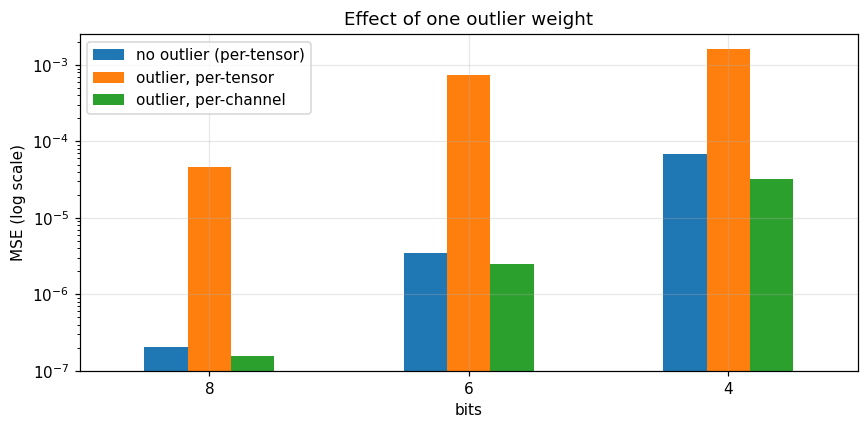

In [11]:
def quantize_per_channel_symmetric(W, num_bits=8):
    qmax = 2 ** (num_bits - 1) - 1
    scales = np.abs(W).max(axis=1, keepdims=True) / qmax     # one scale per row
    q = np.clip(np.round(W / scales), -qmax, qmax).astype(np.int32)
    return q, scales

W_out = W.copy()
W_out[10, 20] = 3.0        # one outlier (~75 standard deviations)

rows = []
for b in [8, 6, 4]:
    q, s = quantize_symmetric(W_out, b)
    e_tensor = mse(W_out, dequantize_symmetric(q, s))
    qc, sc = quantize_per_channel_symmetric(W_out, b)
    e_channel = mse(W_out, sc * qc)
    q0, s0 = quantize_symmetric(W, b)
    e_clean = mse(W, dequantize_symmetric(q0, s0))
    rows.append({"bits": b, "no outlier (per-tensor)": e_clean,
                 "outlier, per-tensor": e_tensor, "outlier, per-channel": e_channel})
outlier_df = pd.DataFrame(rows).set_index("bits")
display(outlier_df)

outlier_df.plot(kind="bar", logy=True, figsize=(8, 4))
plt.ylabel("MSE (log scale)"); plt.title("Effect of one outlier weight")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

**Takeaway:** one outlier makes per-tensor quantization far worse; per-channel (and per-group) scaling almost fully recovers the accuracy. This is why 4-bit LLM methods use small groups/blocks of weights.

## 5. Fake Quantization and Quantization-Aware Training (PyTorch)

In QAT the forward pass uses quantized-then-dequantized weights, while the backward pass uses the straight-through estimator so the model can learn to be robust to rounding.

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class FakeQuantSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, num_bits):
        qmax = 2 ** (num_bits - 1) - 1
        scale = x.abs().max() / qmax
        return torch.clamp(torch.round(x / scale), -qmax, qmax) * scale
    @staticmethod
    def backward(ctx, grad_out):
        return grad_out, None          # straight-through: pass the gradient unchanged

class QATLinear(nn.Linear):
    def __init__(self, *a, num_bits=4, **k):
        super().__init__(*a, **k); self.num_bits = num_bits
    def forward(self, x):
        return F.linear(x, FakeQuantSTE.apply(self.weight, self.num_bits), self.bias)

# Tiny regression task: learn y = sin(x) with a 4-bit-weight network
X = torch.linspace(-3, 3, 512).unsqueeze(1); Y = torch.sin(X)

def train(layer_cls, **kw):
    torch.manual_seed(0)
    net = nn.Sequential(layer_cls(1, 64, **kw), nn.Tanh(), layer_cls(64, 64, **kw), nn.Tanh(), layer_cls(64, 1, **kw))
    opt = torch.optim.Adam(net.parameters(), lr=1e-2)
    for _ in range(600):
        opt.zero_grad(); loss = F.mse_loss(net(X), Y); loss.backward(); opt.step()
    return net, loss.item()

fp_net, fp_loss = train(nn.Linear)
qat_net, qat_loss = train(QATLinear, num_bits=4)

# Post-training quantization of the FP model to 4 bits (no retraining) for comparison
import copy
ptq_net = copy.deepcopy(fp_net)
with torch.no_grad():
    for m in ptq_net:
        if isinstance(m, nn.Linear):
            m.weight.copy_(FakeQuantSTE.apply(m.weight, 4))
ptq_loss = F.mse_loss(ptq_net(X), Y).item()

print(f"FP32 model           MSE: {fp_loss:.5f}")
print(f"4-bit PTQ            MSE: {ptq_loss:.5f}")
print(f"4-bit QAT (fake-quant) MSE: {qat_loss:.5f}")

FP32 model           MSE: 0.00253
4-bit PTQ            MSE: 0.00182
4-bit QAT (fake-quant) MSE: 0.00171


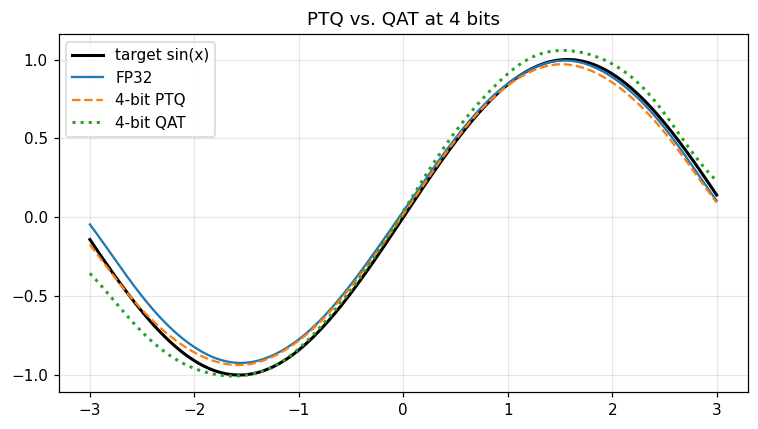

In [13]:
with torch.no_grad():
    plt.figure(figsize=(7, 4))
    plt.plot(X, Y, "k", lw=2, label="target sin(x)")
    plt.plot(X, fp_net(X), label="FP32")
    plt.plot(X, ptq_net(X), "--", label="4-bit PTQ")
    plt.plot(X, qat_net(X), ":", lw=2, label="4-bit QAT")
plt.legend(); plt.title("PTQ vs. QAT at 4 bits"); plt.tight_layout(); plt.show()

QAT typically recovers accuracy that plain PTQ loses at low bit-widths, at the cost of extra training. (On this tiny toy problem the gap is small; it becomes important for low-bit models on real tasks.)

## 6. Quantizing a Real Model: BERT with Dynamic INT8 Quantization

PyTorch's `quantize_dynamic` replaces every `nn.Linear` with an INT8 version: weights are stored as INT8, activations are quantized on the fly. It runs on **CPU**. Embeddings and LayerNorm stay in FP32, so the overall shrink is less than $4\times$.

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = "textattack/bert-base-uncased-SST-2"    # BERT-base fine-tuned for sentiment
tok = AutoTokenizer.from_pretrained(model_name)
bert_fp32 = AutoModelForSequenceClassification.from_pretrained(model_name).eval()

def disk_size_mb(model):
    with tempfile.NamedTemporaryFile(delete=False) as f:
        torch.save(model.state_dict(), f.name)
        size = os.path.getsize(f.name) / 1e6
    os.remove(f.name)
    return size

bert_int8 = torch.quantization.quantize_dynamic(bert_fp32, {torch.nn.Linear}, dtype=torch.qint8)

print(f"Parameters          : {sum(p.numel() for p in bert_fp32.parameters())/1e6:.1f} M")
print(f"FP32 size on disk   : {disk_size_mb(bert_fp32):.1f} MB")
print(f"INT8 size on disk   : {disk_size_mb(bert_int8):.1f} MB")

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_1472/4078123587.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  bert_int8 = torch.quantization.quantize_dynamic(bert_fp32, {torch.nn.Linear}, dtype=torch.qint8)


model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Parameters          : 109.5 M
FP32 size on disk   : 438.0 MB
INT8 size on disk   : 181.5 MB


In [15]:
sentences = [
    "This movie was absolutely wonderful, I loved every minute.",
    "A dull, lifeless film with terrible acting.",
    "The plot was predictable but the soundtrack was great.",
    "I would not recommend this to anyone.",
    "An instant classic and a triumph for the director.",
    "The service was slow and the food was cold.",
    "What a delightful surprise, highly entertaining!",
    "Boring from start to finish.",
]
batch = tok(sentences, return_tensors="pt", padding=True, truncation=True)

@torch.no_grad()
def run(model, n_warm=3, n_iter=20):
    for _ in range(n_warm): model(**batch)
    t0 = time.perf_counter()
    for _ in range(n_iter): out = model(**batch)
    return out.logits, (time.perf_counter() - t0) / n_iter * 1000

logits_fp32, t_fp32 = run(bert_fp32)
logits_int8, t_int8 = run(bert_int8)

pred_fp32, pred_int8 = logits_fp32.argmax(-1), logits_int8.argmax(-1)
print(f"Latency FP32: {t_fp32:.1f} ms | INT8: {t_int8:.1f} ms | speed-up: {t_fp32/t_int8:.2f}x")
print(f"Prediction agreement: {(pred_fp32 == pred_int8).float().mean().item()*100:.0f}%")
print(f"Mean |logit difference|: {(logits_fp32 - logits_int8).abs().mean().item():.4f}")

Latency FP32: 238.6 ms | INT8: 154.1 ms | speed-up: 1.55x
Prediction agreement: 100%
Mean |logit difference|: 1.5063


In [16]:
bert_results = {
    "BERT FP32": {"size_mb": disk_size_mb(bert_fp32), "latency_ms": t_fp32},
    "BERT INT8 (dynamic)": {"size_mb": disk_size_mb(bert_int8), "latency_ms": t_int8},
}
del bert_int8; gc.collect()

2026

**Why not exactly 4× smaller?** Only the `Linear` layers are quantized. The embedding table (~23M parameters for BERT-base) and LayerNorm parameters remain FP32.

## 7. Quantizing a LLaMA-Family Model: 8-bit and 4-bit with `bitsandbytes`

LLaMA-7B is too big for a free Colab GPU in FP16 (~13.5 GB of weights), so we use **TinyLlama-1.1B**, which shares the LLaMA architecture. The same code works for `meta-llama/Llama-2-7b-hf` on a bigger GPU (after accepting the license).

* **8-bit**: LLM.int8() (per-row quantization plus a mixed-precision path for outlier features).
* **4-bit NF4**: NormalFloat4 with block-wise scales, plus optional *double quantization* of the scales (from QLoRA).

In [17]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

llm_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
llm_results = {}

if not torch.cuda.is_available():
    print("No GPU detected. Enable one in Runtime > Change runtime type to run this section.")
else:
    llm_tok = AutoTokenizer.from_pretrained(llm_name)
    prompt = "Explain in one sentence why smaller neural networks are useful on phones."
    inputs = llm_tok(prompt, return_tensors="pt").to("cuda")

    configs = {
        "FP16": dict(torch_dtype=torch.float16),
        "INT8 (LLM.int8)": dict(quantization_config=BitsAndBytesConfig(load_in_8bit=True)),
        "NF4 (4-bit)": dict(quantization_config=BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True, bnb_4bit_compute_dtype=torch.float16)),
    }

    for label, kw in configs.items():
        m = AutoModelForCausalLM.from_pretrained(llm_name, device_map="auto", **kw).eval()
        mem_mb = m.get_memory_footprint() / 1e6
        with torch.no_grad():
            m.generate(**inputs, max_new_tokens=8, do_sample=False)          # warm-up
            torch.cuda.synchronize(); t0 = time.perf_counter()
            out = m.generate(**inputs, max_new_tokens=64, do_sample=False)
            torch.cuda.synchronize(); dt = time.perf_counter() - t0
        n_new = out.shape[1] - inputs["input_ids"].shape[1]
        llm_results[label] = {"size_mb": mem_mb, "latency_ms": dt / n_new * 1000}   # ms per token
        print(f"--- {label}: {mem_mb:.0f} MB, {dt/n_new*1000:.1f} ms/token")
        print(llm_tok.decode(out[0], skip_special_tokens=True)[:300], "\n")
        del m; gc.collect(); torch.cuda.empty_cache()

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

...

[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- INT8 (LLM.int8): 1231 MB, 408.2 ms/token
Explain in one sentence why smaller neural networks are useful on phones. 



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=8) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=64) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


--- NF4 (4-bit): 747 MB, 55.4 ms/token
Explain in one sentence why smaller neural networks are useful on phones. 



> Note: `bitsandbytes` kernels favour *memory* savings. Latency may be equal to or even higher than FP16 for a small model like this, because dequantization adds work. Large models that are memory-bandwidth bound benefit more.

## 8. Results Comparison

In [18]:
def to_df(d, model_label):
    df = pd.DataFrame(d).T
    df.insert(0, "model", model_label)
    return df

frames = [to_df(bert_results, "BERT-base")]
if llm_results:
    frames.append(to_df(llm_results, "TinyLlama-1.1B"))
results = pd.concat(frames)
results.index.name = "precision"
results["size_reduction_x"] = results.groupby("model")["size_mb"].transform(lambda s: s.iloc[0] / s)
results.round(2)

,model,size_mb,latency_ms,size_reduction_x
precision,,,,
BERT FP32,BERT-base,438.02,238.56,1.00
BERT INT8 (dynamic),BERT-base,181.50,154.13,2.41
FP16,TinyLlama-1.1B,2200.10,52.18,1.00
INT8 (LLM.int8),TinyLlama-1.1B,1231.21,408.22,1.79
NF4 (4-bit),TinyLlama-1.1B,746.77,55.39,2.95


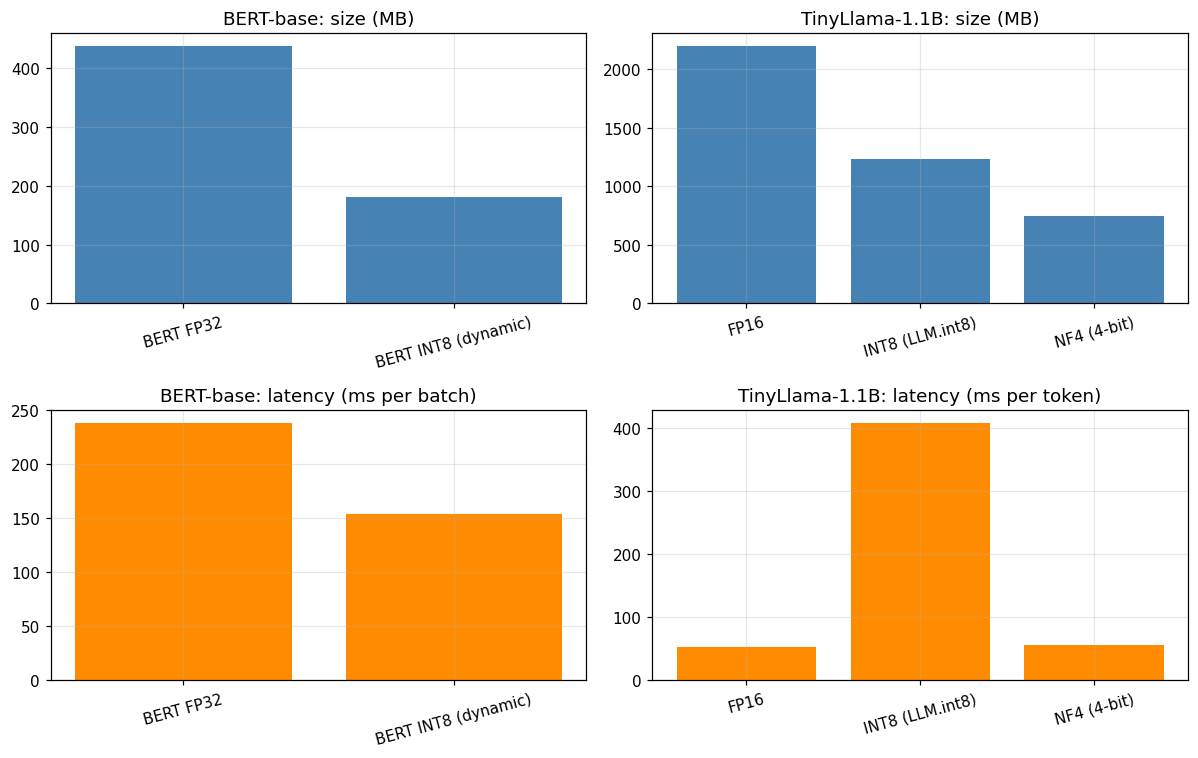

In [19]:
groups = results.groupby("model", sort=False)
fig, axes = plt.subplots(2, len(groups), figsize=(5.5 * len(groups), 7), squeeze=False)
for j, (name, g) in enumerate(groups):
    axes[0, j].bar(g.index, g["size_mb"], color="steelblue")
    axes[0, j].set_title(f"{name}: size (MB)"); axes[0, j].tick_params(axis="x", rotation=15)
    axes[1, j].bar(g.index, g["latency_ms"], color="darkorange")
    unit = "ms per token" if "Llama" in name else "ms per batch"
    axes[1, j].set_title(f"{name}: latency ({unit})"); axes[1, j].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

## 9. Discussion and Conclusion

**How do we address the size problem?** Through model compression: quantization, pruning, distillation, low-rank factorization and weight sharing. Quantization is the most widely used because it needs no architecture change and can be applied to a pretrained model.

**What we showed**
* Storage scales as $N\cdot b/8$, so INT8/INT4 give $4\times$/$8\times$ savings over FP32.
* Rounding error is bounded by $s/2$ and shrinks about $4\times$ per extra bit; 8-bit is close to lossless, and 4-bit needs care.
* A single outlier can ruin per-tensor quantization, while per-channel or per-group scales fix it. This is why modern LLM quantizers work group-wise.
* Dynamic INT8 quantization shrinks BERT with a single line of code and almost no change in predictions. `bitsandbytes` lets a LLaMA-family model load in 8-bit or 4-bit with a config object.

**PTQ vs. QAT.** PTQ is cheap (minutes, little or no data) and usually sufficient at 8 bits. QAT is more accurate at very low bit-widths but requires training, which is expensive for LLM-scale models. For LLMs, practitioners therefore favour smarter PTQ (GPTQ, AWQ) or QLoRA (4-bit frozen base model plus trainable low-rank adapters).

**Limitations**
* Real speed-ups need hardware/kernels that support low-precision arithmetic.
* Accuracy can degrade on sensitive tasks (reasoning, long context) at 4 bits or below.
* Activation outliers in large LLMs make activation quantization harder than weight-only quantization.

**Advanced methods worth knowing:** LLM.int8(), GPTQ, AWQ, SmoothQuant, QLoRA (NF4 + double quantization).

## 10. References

1. B. Jacob et al., *Quantization and Training of Neural Networks for Efficient Integer-Arithmetic-Only Inference*, CVPR 2018.
2. T. Dettmers et al., *LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale*, NeurIPS 2022.
3. T. Dettmers et al., *QLoRA: Efficient Finetuning of Quantized LLMs*, NeurIPS 2023.
4. E. Frantar et al., *GPTQ: Accurate Post-Training Quantization for Generative Pre-trained Transformers*, ICLR 2023.
5. J. Lin et al., *AWQ: Activation-aware Weight Quantization for LLM Compression and Acceleration*, 2023.
6. A. Gholami et al., *A Survey of Quantization Methods for Efficient Neural Network Inference*, 2021.
7. J. Devlin et al., *BERT: Pre-training of Deep Bidirectional Transformers*, 2019; H. Touvron et al., *LLaMA: Open and Efficient Foundation Language Models*, 2023.
8. PyTorch quantization docs; Hugging Face `transformers` quantization guide (`bitsandbytes`).